/Users/yiding/anaconda3/lib/python3.8/site-packages/sklearn/metrics/pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/var/folders/kf/4xn__yc93d35stj58m8nc46m0000gn/T/ipykernel_99460/206537600.py:22: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_kmers = linkage(jaccard_dist, method="average")


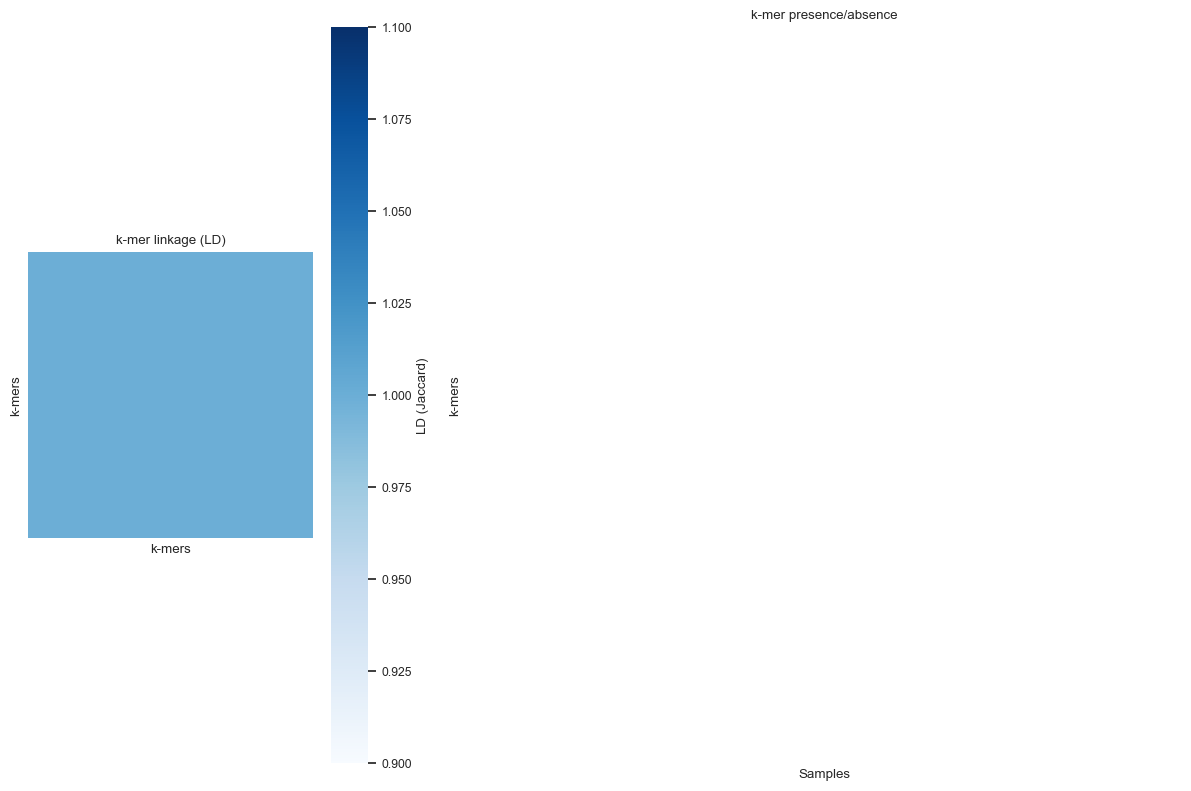

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, leaves_list

# Load sparse matrix and labels
mat = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9B_kmer_matrix_kmers.tsv", header=None)[0].tolist()

# Subset top 100 variable k-mers for better plotting
variance = mat.sum(axis=0)
top_k_idx = np.argsort(variance)[-100:]
mat = mat[:, top_k_idx]
kmers = [kmers[i] for i in top_k_idx]

# Cluster k-mers by Jaccard similarity
jaccard_dist = pairwise_distances(mat.T, metric="jaccard")
linkage_kmers = linkage(jaccard_dist, method="average")
kmer_order = leaves_list(linkage_kmers)

# Cluster samples (optional)
linkage_samples = linkage(mat, method="average")
sample_order = leaves_list(linkage_samples)

# Reorder matrix
mat_ordered = mat[sample_order][:, kmer_order]

# LEFT panel: LD between k-mers (Jaccard similarity)
ld_mat = 1 - jaccard_dist  # convert distance to similarity
ld_mat_ordered = ld_mat[np.ix_(kmer_order, kmer_order)]

# RIGHT panel: presence/absence matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 8), width_ratios=[1, 2])

# LEFT: LD heatmap
sns.heatmap(ld_mat_ordered, ax=axes[0], cmap="Blues", square=True, cbar_kws={"label": "LD (Jaccard)"})
axes[0].set_title("k-mer linkage (LD)")
axes[0].set_xlabel("k-mers")
axes[0].set_ylabel("k-mers")
axes[0].set_xticks([])
axes[0].set_yticks([])

# RIGHT: presence/absence binary heatmap
sns.heatmap(mat_ordered.T, ax=axes[1], cmap=sns.color_palette(["white", "green"]), cbar=False)
axes[1].set_title("k-mer presence/absence")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("k-mers")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

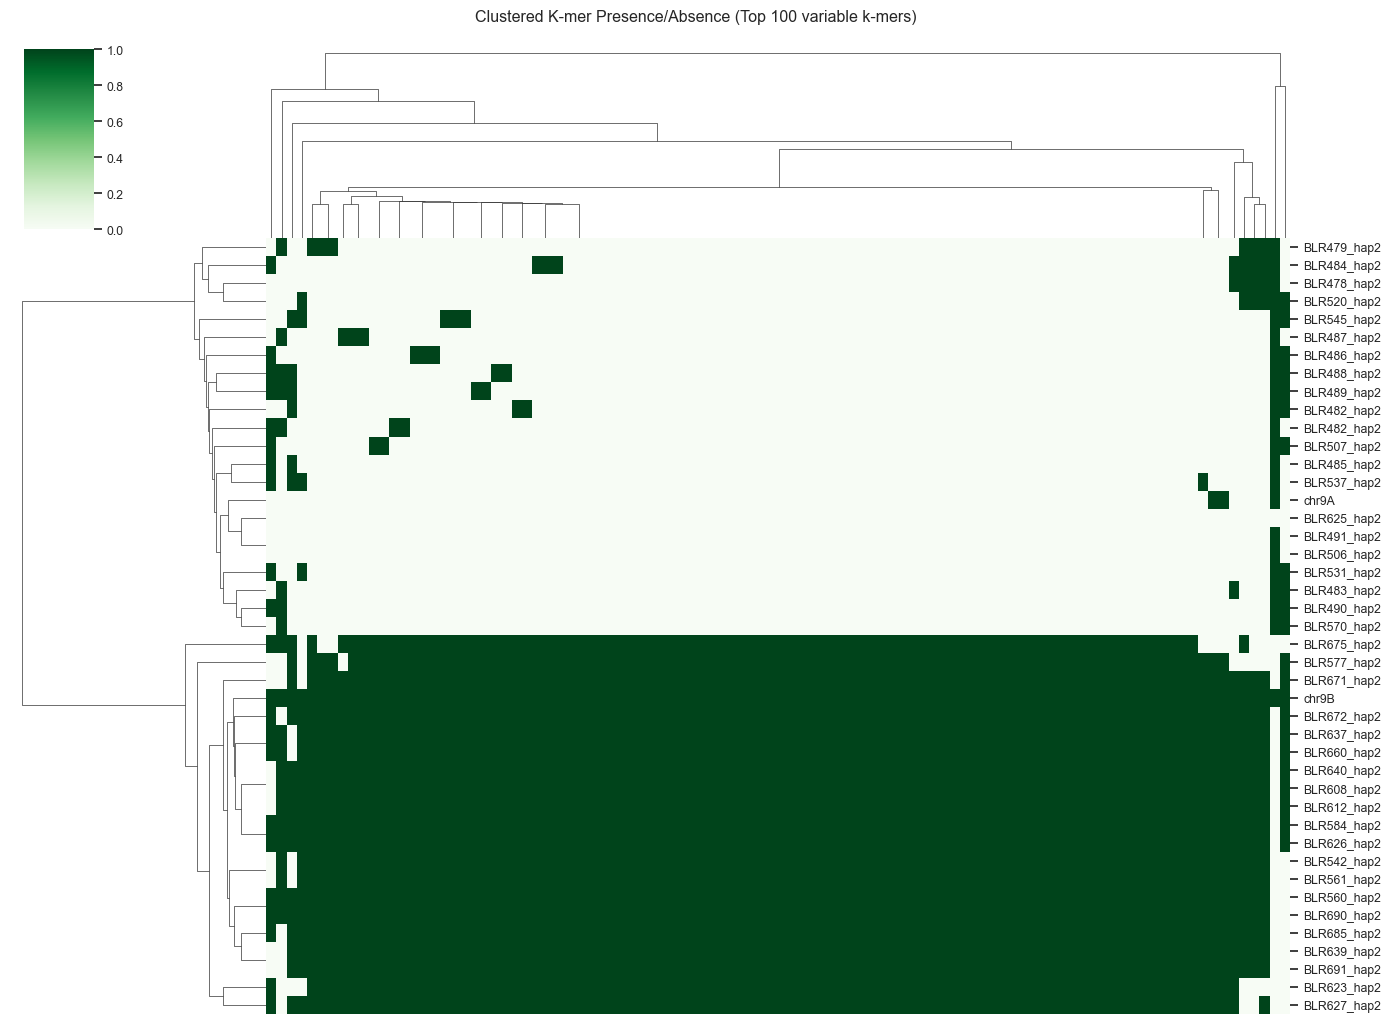

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import load_npz

# Load sparse matrix and metadata
matrix = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9B_kmer_matrix_kmers.tsv", header=None)[0].tolist()

# Select top 100 most variable k-mers
kmer_variance = np.var(matrix, axis=0)
top_k_idx = np.argsort(kmer_variance)[-100:]
matrix_sub = matrix[:, top_k_idx]
kmers_sub = [kmers[i] for i in top_k_idx]

# Create DataFrame for clustermap
df = pd.DataFrame(matrix_sub, index=samples, columns=kmers_sub)

# Plot clustered heatmap
sns.clustermap(
    df,
    metric="euclidean",
    method="average",
    cmap="Greens",
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True
)

plt.suptitle("Clustered K-mer Presence/Absence (Top 100 variable k-mers)", y=1.02)
plt.show()

In [1]:
import pandas as pd
import numpy as np

# Load BED and assign column names
cnv_bed = pd.read_csv("./kmer/chr9B_cnv_segments.bed", sep="\t", header=None,
                      names=["chrom", "start", "end", "sample", "copy_number"])

# Ensure numeric types for calculations
cnv_bed["start"] = pd.to_numeric(cnv_bed["start"], errors="coerce")
cnv_bed["end"] = pd.to_numeric(cnv_bed["end"], errors="coerce")
cnv_bed["copy_number"] = pd.to_numeric(cnv_bed["copy_number"], errors="coerce")

# Drop rows with missing numeric values
cnv_bed.dropna(subset=["start", "end", "copy_number"], inplace=True)

# Compute CNV span and deviation from 2.0 (diploid baseline)
cnv_bed["span"] = cnv_bed["end"] - cnv_bed["start"]
cnv_bed["cn_deviation"] = np.abs(cnv_bed["copy_number"] - 2.0)

# Summarize CNV burden per sample
cnv_summary = cnv_bed.groupby("sample").agg(
    cnv_bp=("span", "sum"),
    cnv_count=("span", "count"),
    mean_cn=("copy_number", "mean"),
    total_deviation=("cn_deviation", "sum"),
    weighted_deviation_bp=("cn_deviation", lambda x: (x * cnv_bed.loc[x.index, "span"]).sum())
).reset_index()

# Save
cnv_summary.to_csv("./kmer/chr9B_cnv_summary.tsv", sep="\t", index=False)


In [81]:
# Load k-mer matrix sample list
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0]
cnv = pd.read_csv("./kmer/chr9B_cnv_summary.tsv", sep="\t")

# Merge with default inner join
annotated = pd.merge(samples.to_frame(name="sample"), cnv, on="sample", how="left")

# Fill missing CNVs (e.g., samples with no CNVs on Chr9A)
annotated = annotated.fillna(0)

# Now use `annotated["total_cnv_bp"]` to annotate heatmaps or groupings

/Users/yiding/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/yiding/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


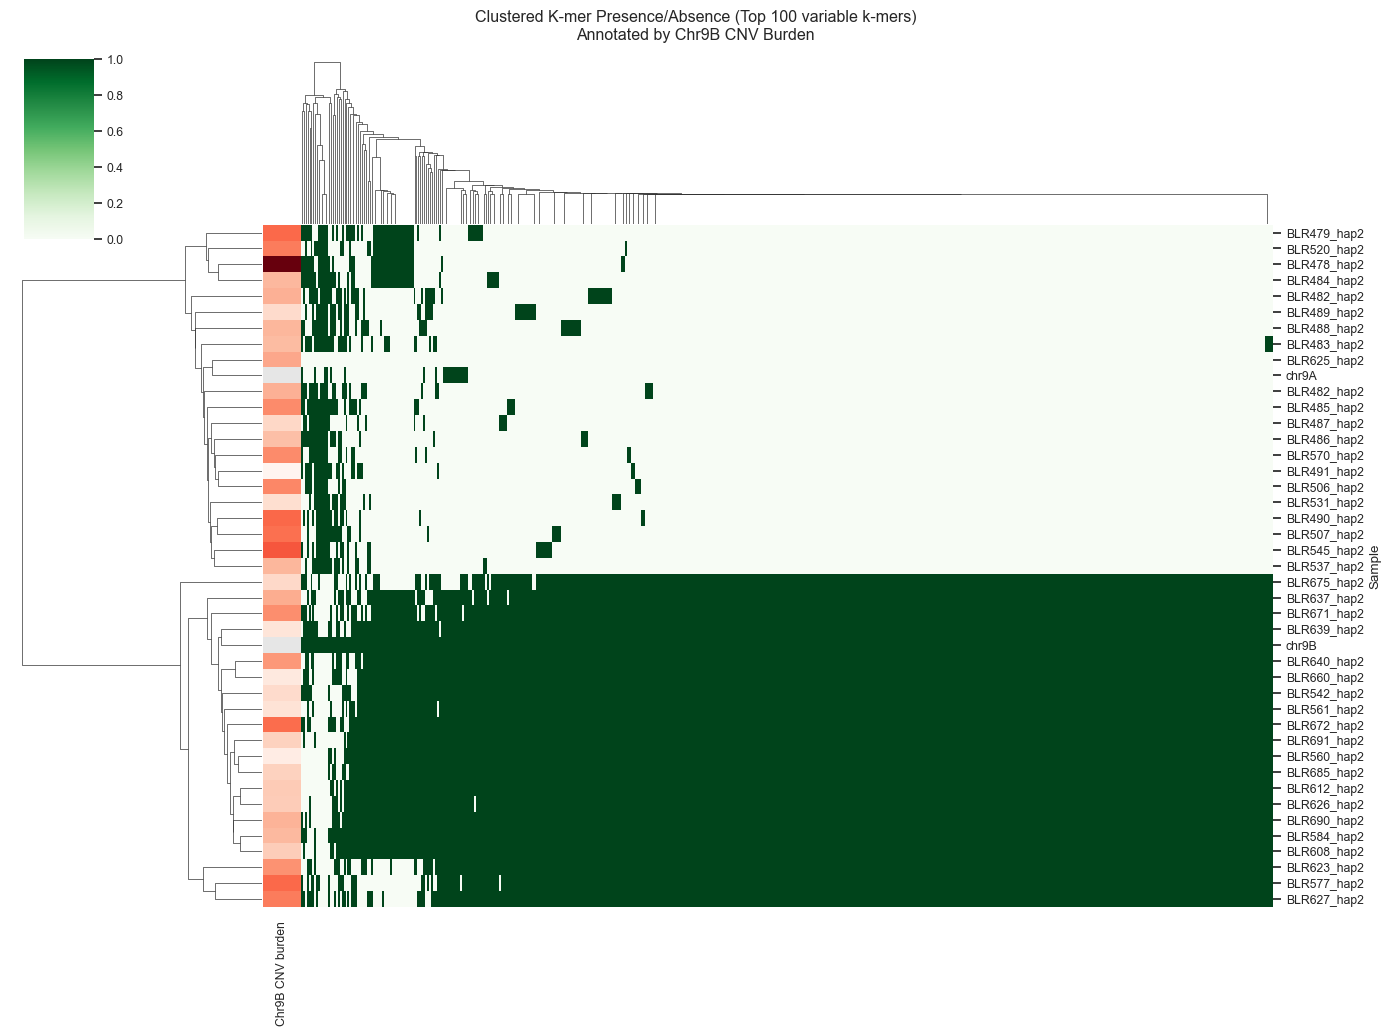

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from matplotlib.colors import Normalize

# --- Load matrix and metadata ---
matrix = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9B_kmer_matrix_kmers.tsv", header=None)[0].tolist()

# --- Select top 100 most variable k-mers ---
kmer_variance = np.var(matrix, axis=0)
top_k_idx = np.argsort(kmer_variance)[-500:]
matrix_sub = matrix[:, top_k_idx]
kmers_sub = [kmers[i] for i in top_k_idx]

# --- Format DataFrame ---
df = pd.DataFrame(matrix_sub, index=samples, columns=kmers_sub)
df.index.name = "Sample"

# --- Load CNV summary and prepare row colors ---
cnv = pd.read_csv("./kmer/chr9B_cnv_summary.tsv", sep="\t").set_index("sample")

# Use CNV metric (e.g. total_deviation or weighted_deviation_bp)
cnv_burden = cnv["total_deviation"].reindex(df.index)

# Normalize and color map
norm = Normalize(vmin=cnv_burden.min(skipna=True), vmax=cnv_burden.max(skipna=True))
row_colors = cnv_burden.map(lambda x: plt.cm.Reds(norm(x)) if pd.notnull(x) else (0.9, 0.9, 0.9, 1))
row_colors_df = pd.DataFrame({"Chr9B CNV burden": row_colors})

pop = pd.read_csv("./kmer/Hap2_based_pop_info.fam", sep="\t").set_index("sample")
custom_colors = {
    "pop1": "#57B893",
    "pop2": "#F87850",
    "pop3": "#7B8DBF",
    "pop4": "#D771B6",
    "pop5": "#B2DF8A"
}
pop_colors = pop["population"].map(custom_colors).reindex(df.index)


# --- Plot clustermap with CNV burden ---
sns.set(font_scale=0.8)
sns.clustermap(
    df,
    metric="euclidean",
    method="average",
    cmap="Greens",
    figsize=(14, 10),
    xticklabels=False,
    yticklabels=True,
    row_colors=row_colors_df
)

plt.suptitle("Clustered K-mer Presence/Absence (Top 100 variable k-mers)\nAnnotated by Chr9B CNV Burden", y=1.03)
plt.show()

cg.savefig("chr9B_kmer_clustered_clustermap_annotated_no_pop.pdf")

/Users/yiding/anaconda3/lib/python3.8/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/Users/yiding/anaconda3/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


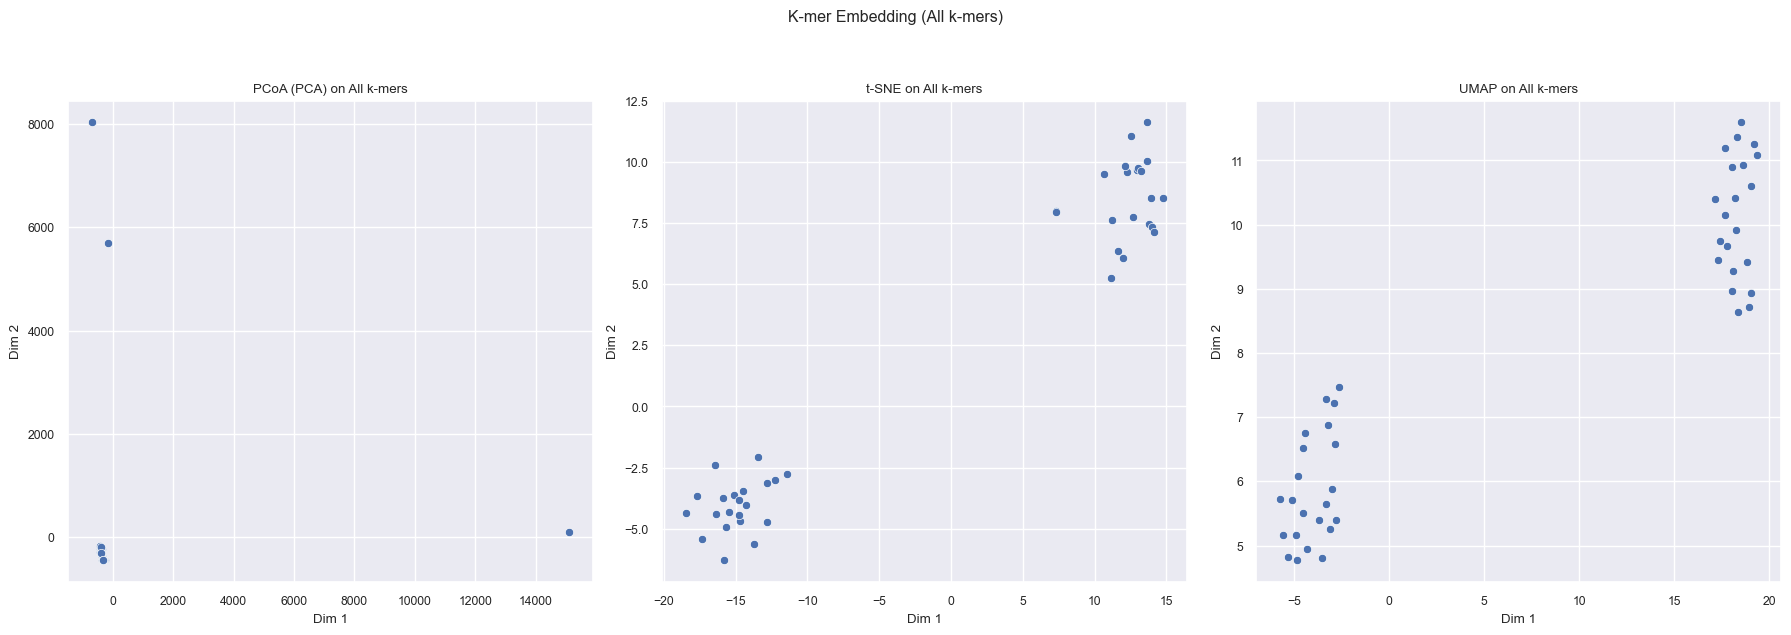

In [321]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# --- Load full sparse matrix ---
matrix = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()

# --- Use all k-mers ---
df_full = pd.DataFrame(matrix, index=samples)

# --- Optional: normalize or filter if needed
from sklearn.preprocessing import StandardScaler
df_full = StandardScaler().fit_transform(df_full)

# --- 1. PCoA via PCA ---
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(df_full)

# --- 2. t-SNE ---
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_coords = tsne.fit_transform(df_full)

# --- 3. UMAP ---
umap_coords = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="hamming", random_state=42).fit_transform(df_full)

# --- Plot function ---
def plot_embedding(coords, title, ax):
    sns.scatterplot(x=coords[:,0], y=coords[:,1], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

# --- Create plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_embedding(pca_coords, "PCoA (PCA) on All k-mers", axes[0])
plot_embedding(tsne_coords, "t-SNE on All k-mers", axes[1])
plot_embedding(umap_coords, "UMAP on All k-mers", axes[2])
plt.suptitle("K-mer Embedding (All k-mers)", y=1.05)
plt.tight_layout()
plt.show()

/Users/yiding/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/yiding/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


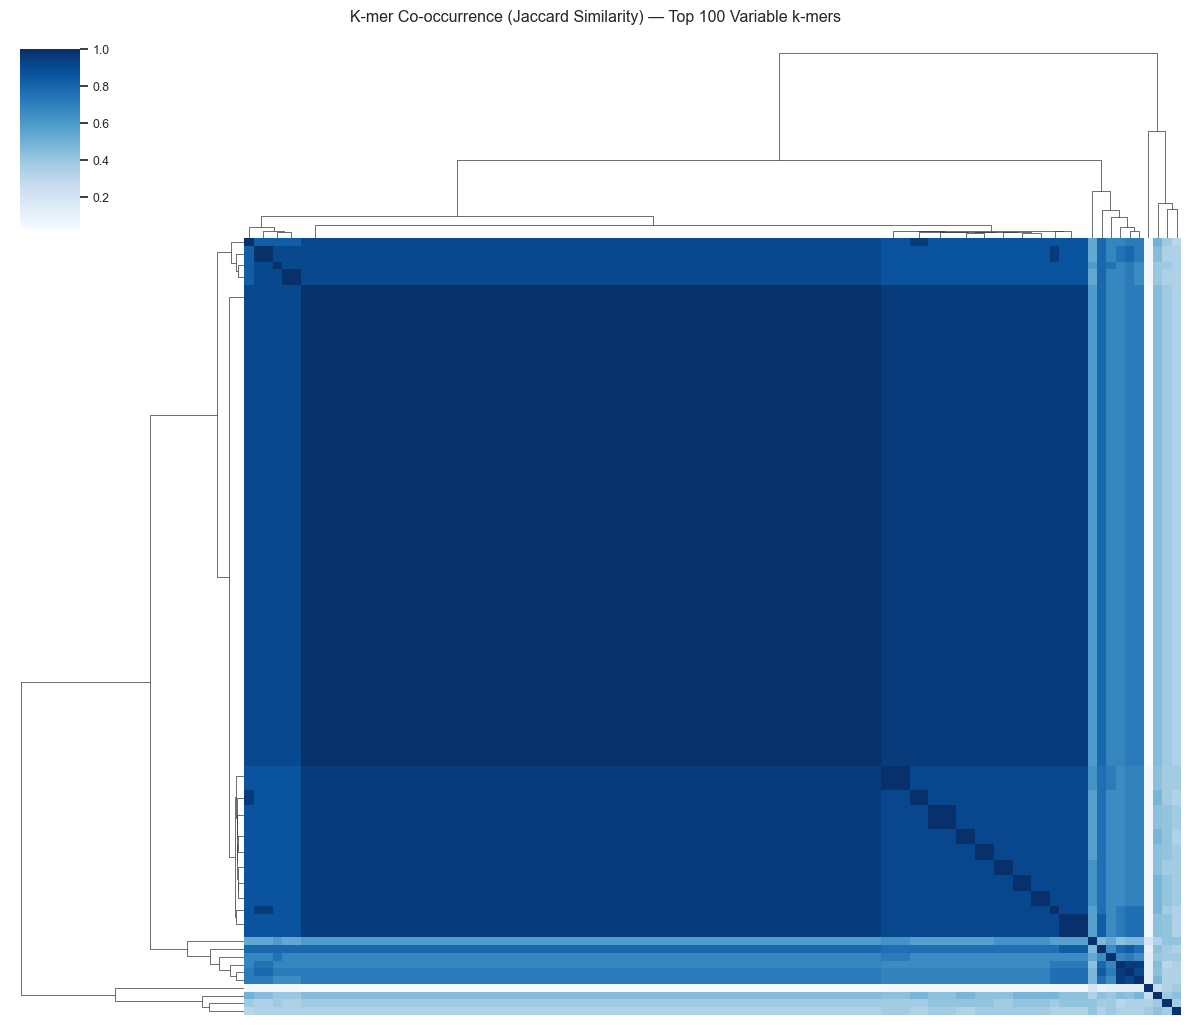

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import load_npz

# Load full matrix and metadata
matrix = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9B_kmer_matrix_kmers.tsv", header=None)[0].tolist()

# --- Select top 100 variable k-mers ---
kmer_variance = np.var(matrix, axis=0)
top_k_idx = np.argsort(kmer_variance)[-100:]
matrix_top = matrix[:, top_k_idx]
kmers_top = [kmers[i] for i in top_k_idx]

# --- Compute pairwise Jaccard similarity ---
# Jaccard distance = 1 - (intersection / union)
# Convert to similarity by (1 - distance)
jaccard_dist = pdist(matrix_top.T, metric='jaccard')
jaccard_sim = 1 - squareform(jaccard_dist)  # k-mer x k-mer

# Create DataFrame for clustermap
jaccard_df = pd.DataFrame(jaccard_sim, index=kmers_top, columns=kmers_top)

# --- Plot heatmap ---
sns.clustermap(
    jaccard_df,
    cmap="Blues",
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=False
)

plt.suptitle("K-mer Co-occurrence (Jaccard Similarity) — Top 100 Variable k-mers", y=1.02)
plt.show()

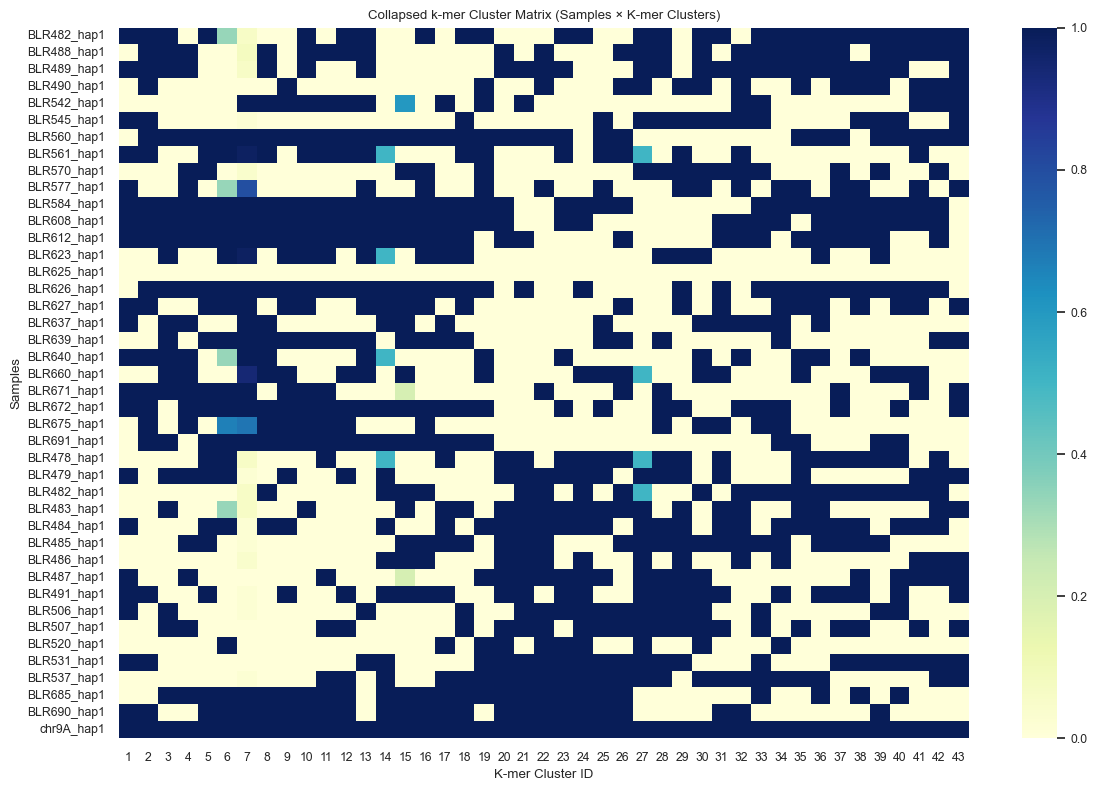

Cluster Summary:
     cluster_id  kmer_count
0            1           1
1            2           1
2            3           1
3            4           1
4            5           2
5            6           3
6            7          49
7            8           1
8            9           1
9           10           1
10          11           1
11          12           1
12          13           1
13          14           2
14          15           5
15          16           1
16          17           1
17          18           1
18          19           1
19          20           1
20          21           1
21          22           1
22          23           1
23          24           1
24          25           1
25          26           1
26          27           2
27          28           1
28          29           1
29          30           1
30          31           1
31          32           1
32          33           1
33          34           1
34          35           1
35        

In [326]:
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
import seaborn as sns
import matplotlib.pyplot as plt

# Load k-mer matrix and metadata
matrix = load_npz("./kmer/chr9_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9_kmer_matrix_kmers.tsv", header=None)[0].tolist()
df = pd.DataFrame(matrix, index=samples, columns=kmers)

# Select top 100 most variable k-mers for speed and interpretation
variances = df.var(axis=0)
top_k_idx = variances.nlargest(100).index
df_top = df[top_k_idx]

# Step 1: Jaccard distance and clustering
binary = df_top.T.astype(bool).astype(int)
jaccard_dist = pdist(binary, metric='jaccard')
link = linkage(jaccard_dist, method='average')

# Step 2: Assign clusters using flat threshold
cluster_ids = fcluster(link, t=0.25, criterion='distance')  # adjust `t` to control number of clusters
cluster_df = pd.DataFrame({'kmer': binary.index, 'cluster': cluster_ids})

# Step 3: Build a collapsed matrix (samples x clusters)
collapsed = pd.DataFrame(0, index=samples, columns=np.unique(cluster_ids))
for cluster_id in np.unique(cluster_ids):
    kmer_set = cluster_df[cluster_df['cluster'] == cluster_id]['kmer']
    collapsed[cluster_id] = df[kmer_set].sum(axis=1)

# Step 4: Normalize cluster matrix (optional)
norm = collapsed.div(collapsed.max(axis=0), axis=1)

# Step 5: Plot heatmap to visualize sample-cluster matrix
plt.figure(figsize=(12, 8))
sns.heatmap(norm, cmap="YlGnBu", yticklabels=True, xticklabels=True)
plt.title("Collapsed k-mer Cluster Matrix (Samples × K-mer Clusters)")
plt.xlabel("K-mer Cluster ID")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

# Step 6: Print cluster summary
summary = cluster_df.groupby('cluster')['kmer'].count().reset_index()
summary.columns = ['cluster_id', 'kmer_count']
print("Cluster Summary:\n", summary)

# Optional: Save results
summary.to_csv("chr9A_kmer_cluster_summary.tsv", sep="\t", index=False)
collapsed.to_csv("chr9A_sample_by_kmer_cluster_matrix.tsv", sep="\t")
# Save k-mer cluster assignments
cluster_df.to_csv("chr9A_kmer_cluster_assignments.tsv", sep="\t", index=False)
print("Saved k-mer to cluster assignments → chr9B_kmer_cluster_assignments.tsv")

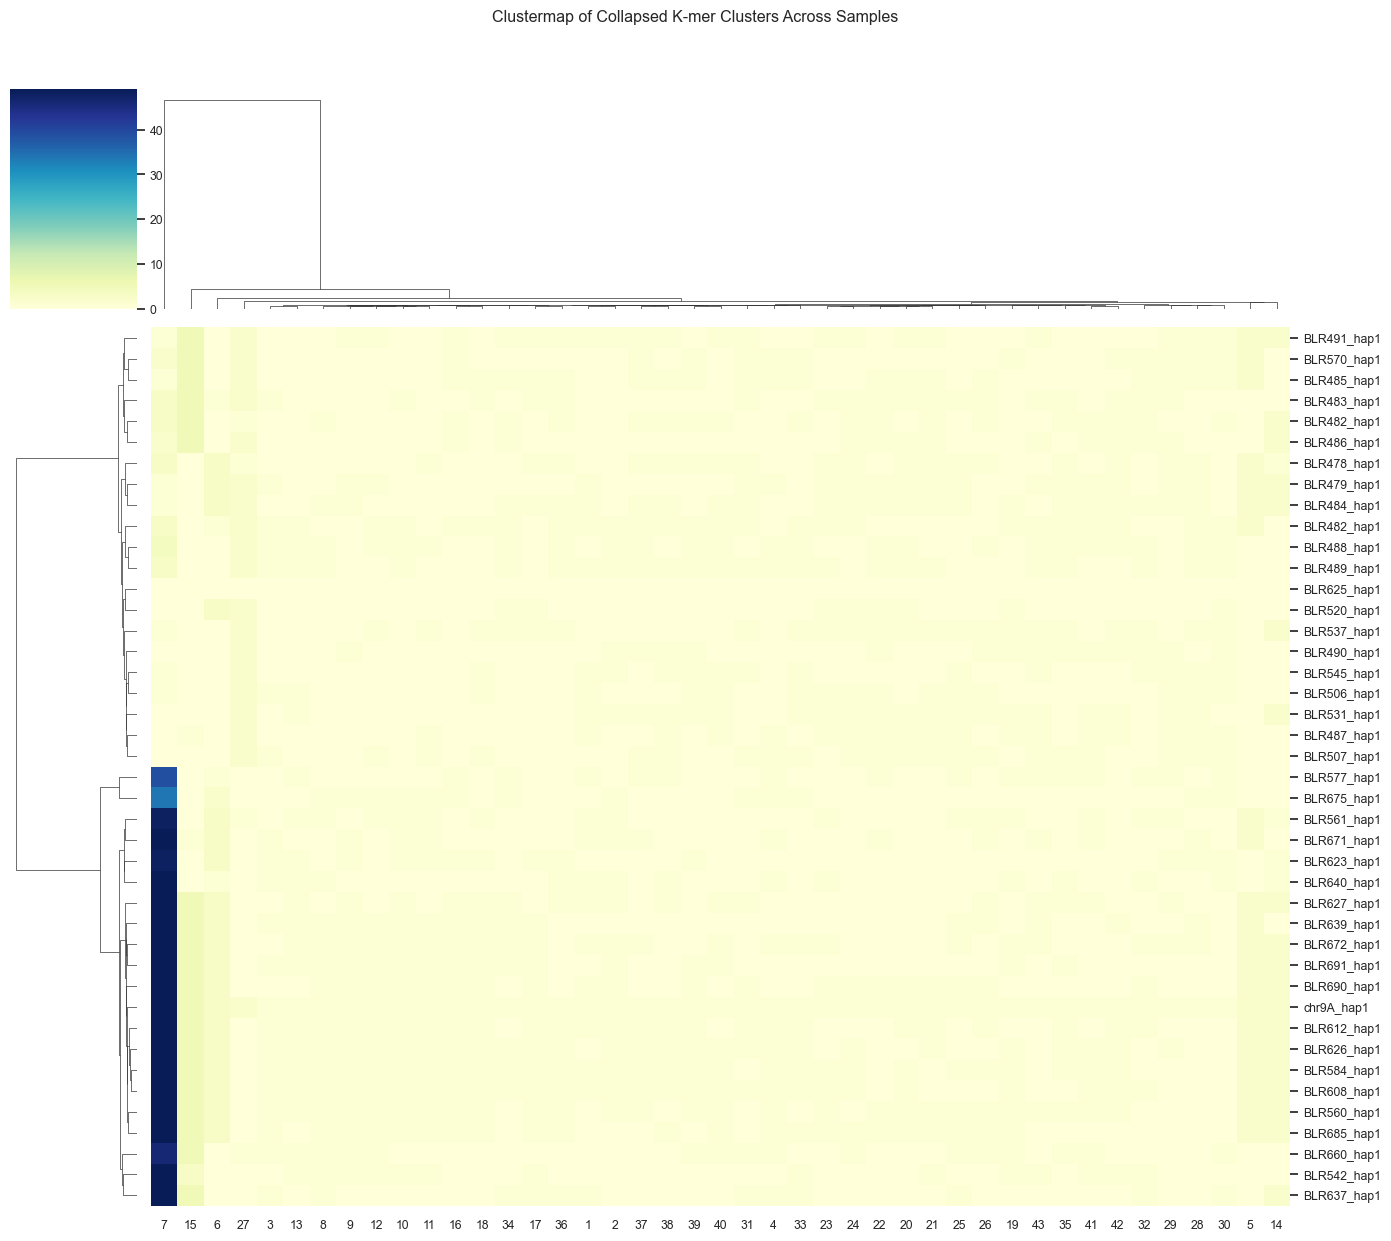

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

In [328]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the collapsed matrix: rows = samples, columns = k-mer clusters
collapsed_df = pd.read_csv("chr9A_sample_by_kmer_cluster_matrix.tsv", sep="\t", index_col=0)

# Optional: standardize per column (z-score or proportion), depending on your preference
# collapsed_df = collapsed_df.div(collapsed_df.max(axis=0), axis=1)  # normalize 0–1 per cluster

# Create clustered heatmap
sns.set(font_scale=0.8)
g=sns.clustermap(
    collapsed_df,
    cmap="YlGnBu",            # Color scheme: yellow to green-blue
    metric="euclidean",       # Distance metric for clustering
    method="average",         # Linkage method
    figsize=(14, 12),
    xticklabels=True,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)  # optional: move colorbar
)

plt.suptitle("Clustermap of Collapsed K-mer Clusters Across Samples", y=1.03)
plt.tight_layout()
plt.show()

g.savefig("chr9A_kmer_clustered_clustermap_green_annotated_no_pop.pdf")

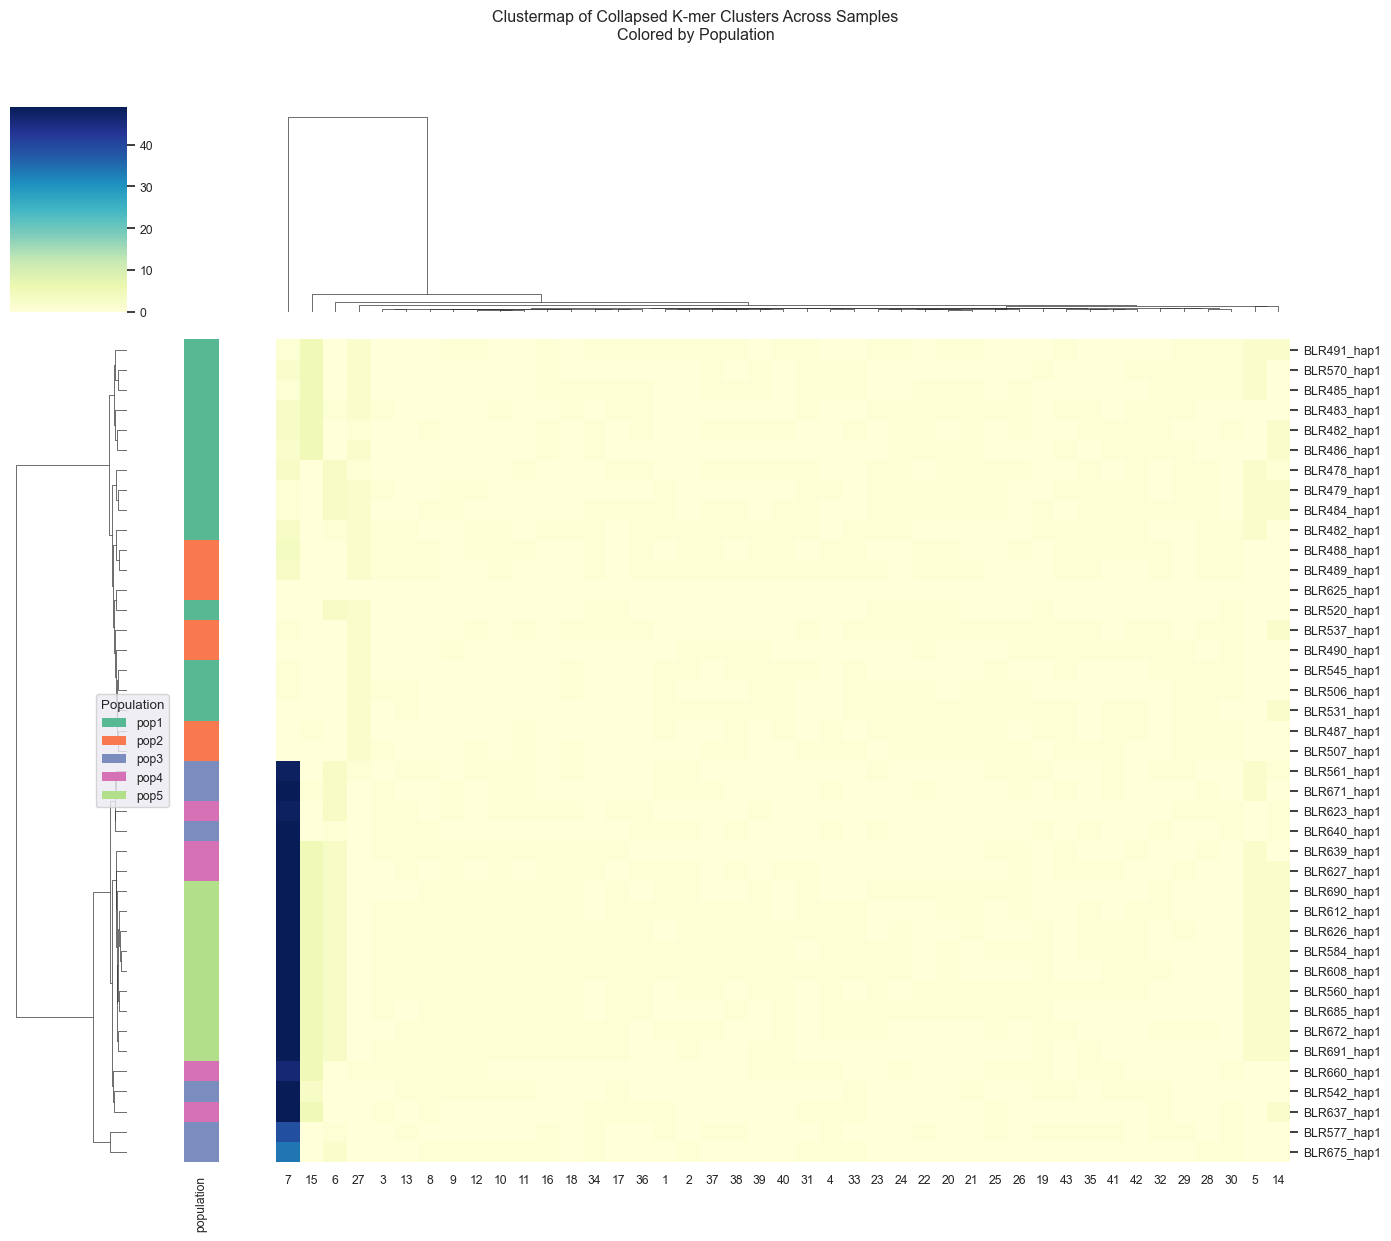

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

In [329]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load collapsed matrix
collapsed_df = pd.read_csv("chr9A_sample_by_kmer_cluster_matrix.tsv", sep="\t", index_col=0)
collapsed_df = collapsed_df[~collapsed_df.index.str.contains("chr9B")]
collapsed_df = collapsed_df[~collapsed_df.index.str.contains("chr9A")]

# Load population info: assume tab-separated file with columns [sample, population]
pop_df = pd.read_csv("./Hap1_based_pop_info.fam", sep="\t", names=["sample", "population"])

# Ensure sample names match collapsed_df index
pop_df = pop_df.set_index("sample").loc[collapsed_df.index]

# Map populations to colors
pop_palette = {
    "pop1": "#57B893",  # blue
    "pop2": "#F87850",  # red
    "pop3": "#7B8DBF",  # green
    "pop4": "#D771B6",  # orange
    "pop5": "#B2DF8A"   # purple
}
row_colors = pop_df["population"].map(pop_palette)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

steel_cmap = LinearSegmentedColormap.from_list("white_to_steelblue", ["#FFFFFF", "#7B8DBF"])

# Clustermap with row color annotation
sns.set(font_scale=0.8)
g = sns.clustermap(
    collapsed_df,
    cmap="YlGnBu",
    metric="euclidean",
    method="average",
    figsize=(14, 12),
    xticklabels=True,
    yticklabels=True,
    row_colors=row_colors,
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)
)

# Add legend for population colors
for pop, color in pop_palette.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=pop, linewidth=0)
g.ax_row_dendrogram.legend(loc="center", ncol=1, title="Population", bbox_to_anchor=(1.05, 0.5))

plt.suptitle("Clustermap of Collapsed K-mer Clusters Across Samples\nColored by Population", y=1.03)
plt.tight_layout()
plt.show()

g.savefig("chr9A_kmer_clustered_clustermap_blue_annotated_with_pop.pdf")

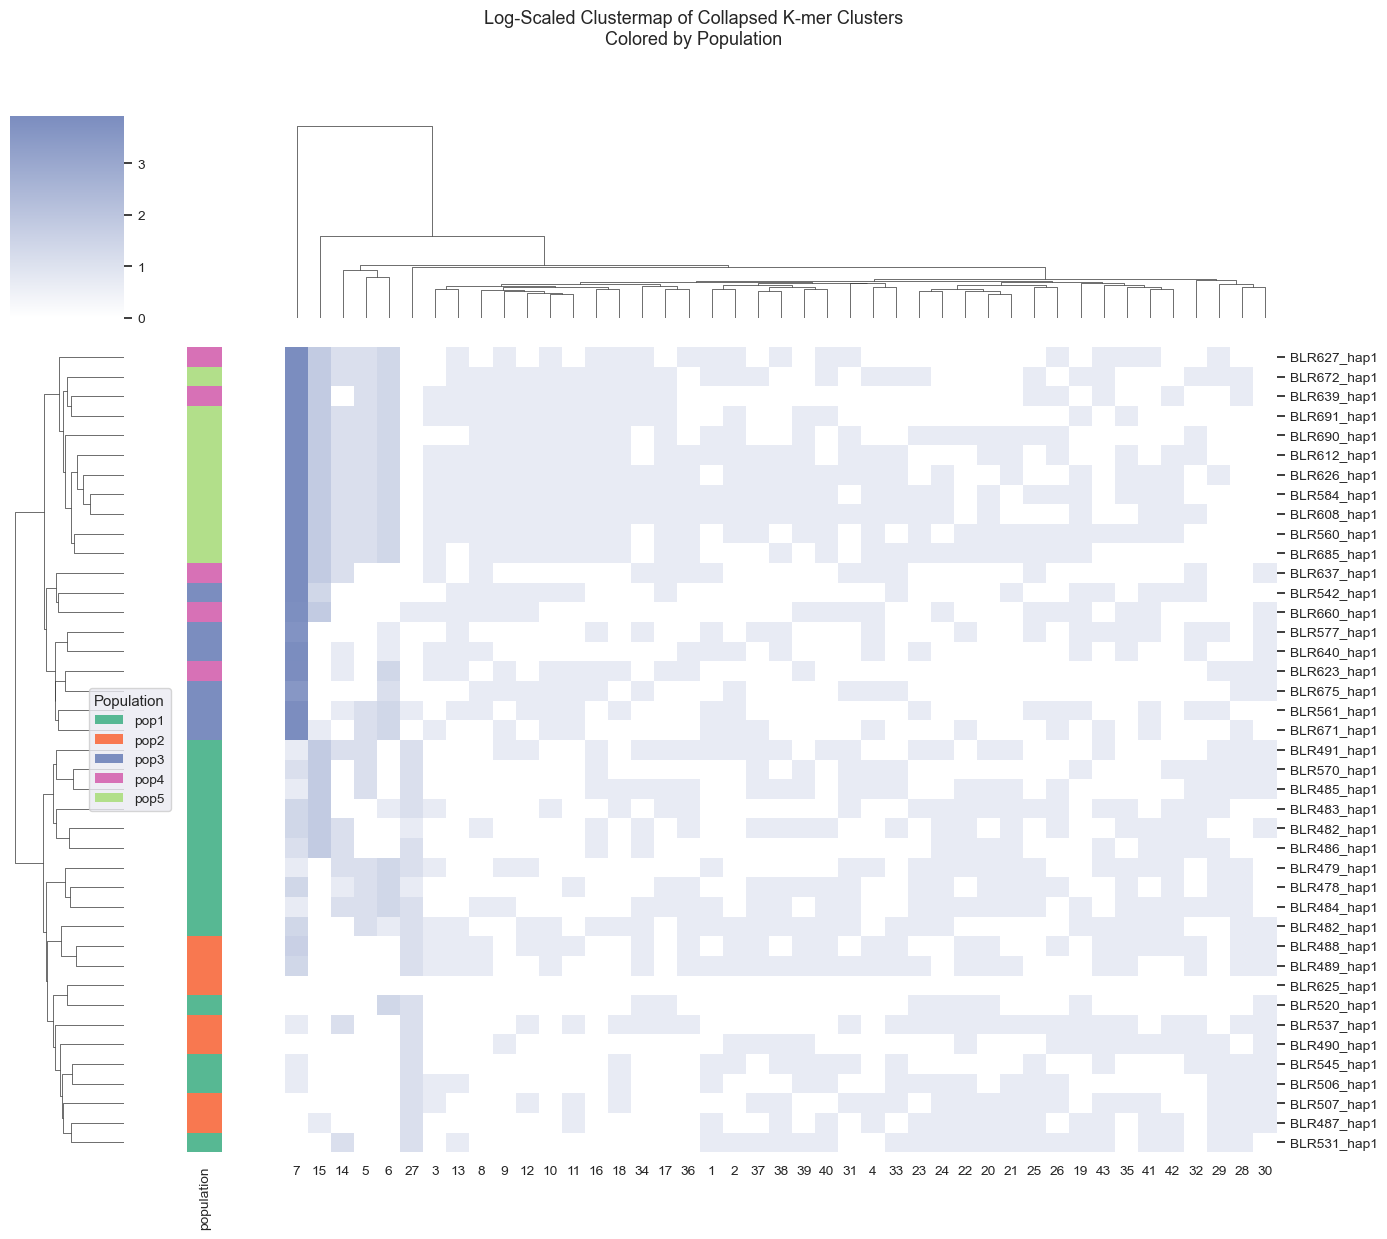

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, san

In [340]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------
# Load collapsed matrix
# -------------------------------
collapsed_df = pd.read_csv("chr9A_sample_by_kmer_cluster_matrix.tsv", sep="\t", index_col=0)
collapsed_df = collapsed_df[~collapsed_df.index.str.contains("chr9B|chr9A")]

# -------------------------------
# Log1p transformation
# -------------------------------
collapsed_df_log = np.log1p(collapsed_df)

# -------------------------------
# Load population info
# -------------------------------
pop_df = pd.read_csv("./Hap1_based_pop_info.fam", sep="\t", names=["sample", "population"])
pop_df = pop_df.set_index("sample").loc[collapsed_df_log.index]

pop_palette = {
    "pop1": "#57B893",
    "pop2": "#F87850",
    "pop3": "#7B8DBF",
    "pop4": "#D771B6",
    "pop5": "#B2DF8A"
}
row_colors = pop_df["population"].map(pop_palette)

# -------------------------------
# Custom color map
# -------------------------------
cmap = LinearSegmentedColormap.from_list("custom_cmap", ["#FFFFFF", "#7B8DBF"])

# -------------------------------
# Plot clustermap
# -------------------------------
sns.set(font_scale=0.9)
g = sns.clustermap(
    collapsed_df_log,
    cmap=cmap,
    metric="euclidean",
    method="average",
    figsize=(14, 12),
    xticklabels=True,
    yticklabels=True,
    row_colors=row_colors,
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)
)

# Legend
for pop, color in pop_palette.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=pop, linewidth=0)
g.ax_row_dendrogram.legend(loc="center", ncol=1, title="Population", bbox_to_anchor=(1.05, 0.5))

plt.suptitle("Log-Scaled Clustermap of Collapsed K-mer Clusters\nColored by Population", y=1.03)
plt.tight_layout()
plt.show()

g.savefig("chr9A_kmer_cluster_clustermap_log1p.pdf")

/Users/yiding/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


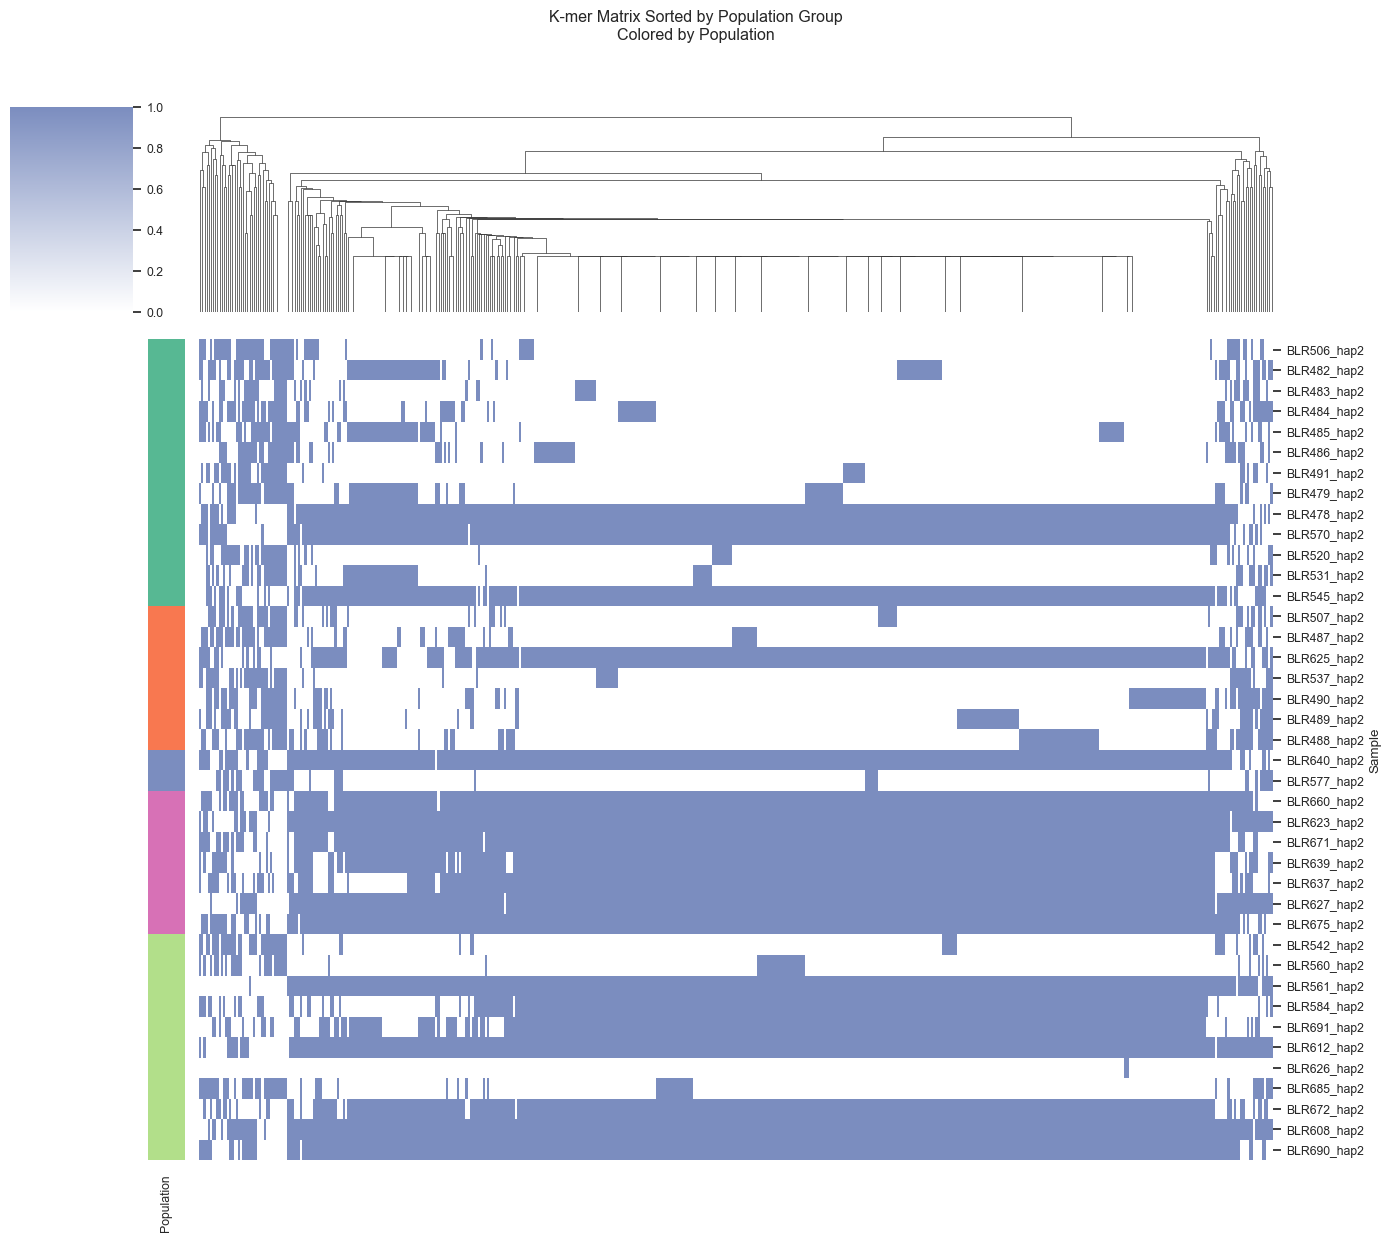

findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Aria

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from matplotlib.colors import Normalize, LinearSegmentedColormap  # FIX: import here
import matplotlib as mpl
mpl.rcParams['pdf.use14corefonts'] = True

# ------------------------
# Load matrix and metadata
# ------------------------
matrix = load_npz("./kmer/chr9B_kmer_matrix.npz").toarray()
samples = pd.read_csv("./kmer/chr9B_kmer_matrix_samples.tsv", header=None)[0].tolist()
kmers = pd.read_csv("./kmer/chr9B_kmer_matrix_kmers.tsv", header=None)[0].tolist()

# Remove reference sample if present
for ref in ["chr9A", "chr9B"]:
    if ref in samples:
        idx = samples.index(ref)
        matrix = np.delete(matrix, idx, axis=0)
        samples.pop(idx)

# ------------------------
# Remove duplicate sample names — keep only first occurrence
# ------------------------
seen = set()
unique_indices = []
unique_samples = []

for i, s in enumerate(samples):
    if s not in seen:
        seen.add(s)
        unique_indices.append(i)
        unique_samples.append(s)

matrix = matrix[unique_indices, :]
samples = unique_samples

# ------------------------
# Select top 500 most variable k-mers
# ------------------------
kmer_variance = np.var(matrix, axis=0)
top_k_idx = np.argsort(kmer_variance)[-500:]
matrix_sub = matrix[:, top_k_idx]
kmers_sub = [kmers[i] for i in top_k_idx]

# Create DataFrame
df = pd.DataFrame(matrix_sub, index=samples, columns=kmers_sub)
df.index.name = "Sample"

# ------------------------
# Load population metadata
# ------------------------
pop = pd.read_csv("./kmer/Hap2_based_pop_info.fam", sep="\t").set_index("sample")
custom_colors = {
    "pop1": "#57B893",  # blue-green
    "pop2": "#F87850",  # red-orange
    "pop3": "#7B8DBF",  # steel blue
    "pop4": "#D771B6",  # pink
    "pop5": "#B2DF8A"   # light green
}
pop_group = pop["population"].reindex(df.index)
pop_colors = pop_group.map(custom_colors)

# ------------------------
# Combine row colors
# ------------------------
row_colors_df = pd.DataFrame({"Population": pop_colors}, index=df.index)

# ------------------------
# Sort samples by population
# ------------------------
sorted_samples = pop_group.sort_values().index
df_sorted = df.loc[sorted_samples]
row_colors_sorted = row_colors_df.loc[sorted_samples]

# ------------------------
# Plot without clustering
# ------------------------
steel_cmap = LinearSegmentedColormap.from_list("white_to_steelblue", ["#FFFFFF", "#7B8DBF"])

sns.set(font_scale=0.8)
g = sns.clustermap(
    df_sorted,
    row_cluster=False,        # disable row clustering
    col_cluster=True,         # keep clustering columns (k-mers)
    row_colors=row_colors_sorted,
    cmap=steel_cmap,
    figsize=(14, 12),
    xticklabels=False,
    yticklabels=True,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)
)

plt.suptitle("K-mer Matrix Sorted by Population Group\nColored by Population", y=1.03)
plt.tight_layout()
plt.show()

g.savefig("Chr9B_kmer_matrix_sorted_by_population_group_new.pdf")